In [4]:
# reading tsv.gz file to dataframe 

import pandas as pd
import gzip
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

PATH_TRAIN = '/media/alvarinho/dados/Estudos/traducao-rede-neural/data/en-pt_BR.txt'

In [2]:
from itertools import islice

n = 20_000_000  # number of lines to read
qtde_pego = 0

pairs = []

progress = tqdm(total=n, desc="Reading lines", unit="line")
with open(f"{PATH_TRAIN}/OpenSubtitles.en-pt_BR.en", encoding="utf-8") as f_en, \
     open(f"{PATH_TRAIN}/OpenSubtitles.en-pt_BR.pt_BR", encoding="utf-8") as f_pt:

    for en, pt in zip(f_en, f_pt):
        if en.strip() and len(en.strip()) > 100:
            pairs.append((en.strip(), pt.strip()))
            qtde_pego += 1
            progress.update(1)
        if qtde_pego >= n:
            break

Reading lines:  16%|█▌        | 3179774/20000000 [00:53<04:02, 69338.26line/s]

Reading lines:  16%|█▌        | 3181098/20000000 [01:10<04:02, 69338.26line/s]

In [3]:
# exemplo
for en, pt in pairs[:5]:
    print("EN:", en.strip())
    print("PT:", pt.strip())
    print()

EN: Director Mueller just assigned us a major case number. Investigation''s  officially been dubbed Amerithrax. Whoever sent these  letters got their Anthrax from an American lab.
PT: o diretor mueller acaba de nomear nos um número de caso principal, investigações foi oficialmente dublado amerithrax, quemosenviou cartas receberam antraz de um laboratório americano, nós não estaríamos aqui se nós não tinha provas nos conduzindo de volta para usamriid,

EN: Bruce Ivins is our top anthrax man. Then I wanna talk to him. They''re treating us like we''re the enemy.
PT: bruce ivins é o nosso melhor homem com antraz, então eu quero falar com ele, eles estão nos tratando como se fôssemos o inimigo, nós somos os heróis, a entrada tem que ser através do complexo de seu herói,

EN: I know most Americans aren''t paying attention, but you guys had signs that 9/11 was gonna happen. And now you can''t figure  out who sent these letters. So instead you are harassing hard working patriots like me.
PT: e

In [6]:
df = pd.DataFrame(pairs, columns=["en", "pt"])

In [7]:
df = df.loc[
    (df['en'].str.len() > 100)
]

In [8]:
df = df.drop_duplicates(subset='en')

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 3154284 entries, 0 to 3181097
Data columns (total 2 columns):
 #   Column  Dtype
---  ------  -----
 0   en      str  
 1   pt      str  
dtypes: str(2)
memory usage: 824.1 MB


In [10]:
df.head(10)

,en,pt
0,Director Mueller just assigned us a major case...,o diretor mueller acaba de nomear nos um númer...
1,Bruce Ivins is our top anthrax man. Then I wan...,"bruce ivins é o nosso melhor homem com antraz,..."
2,I know most Americans aren''t paying attention...,eu conheço a maioria dos americanos não estão ...
3,I had obsessive behaviors linked to sororitie...,tiveobsessivo comportamentos ligados a irmanda...
4,FBI agents searched the home of Steven Hatfil...,:fbi agentes vasculharam a casa de steven hat...
5,Just crushing some chlorpromazine pills for Mr...,só esmagando algumas pílulas de clorpromazina ...
6,"Press the other side and there, it''s called a...","pressione o outro lado e ali, é chamado de do ..."
7,The map we found at Hatfill''s spans acres of ...,o mapa que encontramos nos vãos de hatfill hec...
8,"Come on, the guy wrote a book about a biologic...","vamos lá, o cara escreveu um livro sobre um bi..."
9,"Then again, maybe he''s like any of us, made a...",fez alguns questionáveis julgamento chama na v...


In [11]:
examples = df.sample(10)

for _, row in examples.iterrows():
    print("EN:", row['en'])
    print("PT:", row['pt'])
    print()

EN: Noona, today, are you going on a blind date? â" I kept tossing and turning at thoughts of you. I'm not sureâ â"
PT: Noona, hoje você vai a um encontro às cegas?

EN: ROB: I remember ice-skating around Prince Alfred Park when we first moved from the country to the city.
PT: -Lembro de estar partinando no gelo perto de Prince Alfred Park logo que viemos do interior para a cidade.

EN: [Castle] After John did Dark Star, and it was very good, actually, got a little bit of recognition...
PT: Depois que John fez Dark Star, e foi muito bom, na verdade, ele ganhou certa fama.

EN: The device is using some kind of a telepathic signal... to control people, to use them to keep us from shutting it down.
PT: O artefato está controlando as pessoas telepaticamente... para evitar que o desliguemos.

EN: But I don't, so she just doesn't understand why I would Want to go into the slums and work with the smaller caste people.
PT: Mas eu, não. Então, ela não entende... porque eu quero ir para as f

In [12]:
df['en_length'] = df['en'].str.len()
df['pt_length'] = df['pt'].str.len()

In [13]:
df['en_length'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count    3.154284e+06
mean     1.304542e+02
std      3.136956e+01
min      1.010000e+02
25%      1.090000e+02
50%      1.210000e+02
75%      1.410000e+02
90%      1.710000e+02
95%      1.940000e+02
99%      2.420000e+02
max      3.269000e+03
Name: en_length, dtype: float64

In [14]:
df = df[df['en_length'] <= df['en_length'].quantile(0.90)]

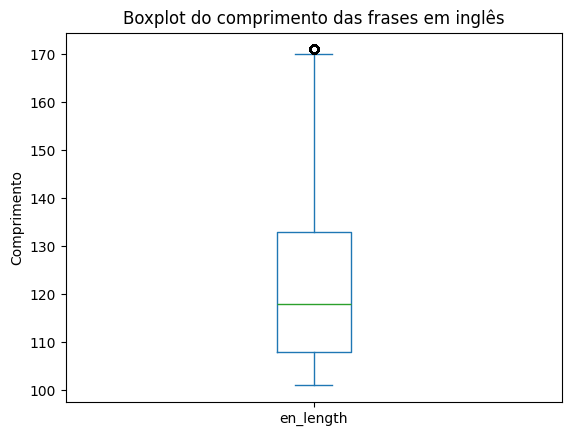

In [15]:
df['en_length'].plot.box()
plt.title("Boxplot do comprimento das frases em inglês")
plt.ylabel("Comprimento")
plt.show()

In [16]:
len(df)

2843363

In [17]:
df = df[
    (df['pt_length'] >= (df['en_length'] * 0.90)) &
    (df['pt_length'] <= (df['en_length'] * 1.1))
    ]

In [18]:
len(df)

1185194

In [19]:
df

,en,pt,en_length,pt_length
3,I had obsessive behaviors linked to sororitie...,tiveobsessivo comportamentos ligados a irmanda...,143,137
12,Seemed to avoid the Seventh Circle of Hell for...,parecia evitar o sétimo círculo do inferno por...,102,109
20,Yes. We finally developed the test that will d...,"sim, finalmente desenvolvemos o teste que irá ...",156,158
24,"You know, it sounds you''ve got something weig...","você sabe, parece você tem algo pesando em seu...",126,121
31,I don''t understand why the FBI''s hounding us...,não entendo por que o fbi está nos perseguindo...,118,122
...,...,...,...,...
3181090,"What I wanted to tell you here today, is that ...","O que eu queria dizer-lhes hoje, é que este pa...",129,120
3181092,I've worked in the free press for over 25 year...,Eu trabalhei na imprensa sem censura por mais ...,102,99
3181093,"And that ""game"" you mentioned... if that's wha...","E esse ""jogo"" que você mencionou... se é o que...",101,106
3181094,"It's one thing to understand the situation, an...","Uma coisa é entender a situação, a outra é dei...",115,105


In [20]:
df['en'] = df['en'].str.capitalize()
df['pt'] = df['pt'].str.capitalize()

In [21]:
df['en'] = df.apply(lambda x: x['en'][:-1] if x['en'][-1] in [','] else x['en'], axis=1)
df['pt'] = df.apply(lambda x: x['pt'][:-1] if x['pt'][-1] in [','] else x['pt'], axis=1)

In [22]:
df['en'] = df.apply(lambda x: x['en']+'.' if x['en'][-1] not in ['.', '!', '?'] else x['en'], axis=1)
df['pt'] = df.apply(lambda x: x['pt']+'.' if x['pt'][-1] not in ['.', '!', '?'] else x['pt'], axis=1)

In [23]:
df['en_max_len_word'] = df['en'].apply(lambda x: max(len(word) for word in x.split()))
df['pt_max_len_word'] = df['pt'].apply(lambda x: max(len(word) for word in x.split()))

In [24]:
df.en_max_len_word.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count    1.185194e+06
mean     1.023332e+01
std      2.224940e+00
min      2.000000e+00
25%      9.000000e+00
50%      1.000000e+01
75%      1.100000e+01
90%      1.300000e+01
95%      1.400000e+01
99%      1.700000e+01
max      8.100000e+01
Name: en_max_len_word, dtype: float64

In [25]:
df.loc[df['en_max_len_word'] > 20].en.values[100]

'Your great-great-grandfather, cedric moon... by skillful management and careful husbandry... increased that sum a hundredfold.'

In [26]:
df = df.loc[df['en_max_len_word'] <= df['en_max_len_word'].quantile(0.9)]
df = df.loc[df['pt_max_len_word'] <= df['pt_max_len_word'].quantile(0.9)]

In [27]:
df = df[len(df['pt'].str.split())]

KeyError: 1003104

In [28]:
df = df.reset_index(drop=True)

In [29]:
index = int(df.sample(1).index[0])
print(df.en.values[index])
print(df.pt.values[index])

But when gretchen gave us gene's case files, i did not know that she was gonna give us all of gene's case files.
Quando gretchen nos deu os arquivos do caso de gene, não sabia que ela nos daria todos os arquivos do caso.


In [30]:
train_df = df.sample(frac=0.8, random_state=42)
eval_test_df = df.drop(train_df.index)
test_df = eval_test_df.sample(frac=0.8, random_state=42)
eval_df = eval_test_df.drop(test_df.index)

In [32]:
len(train_df), len(eval_df), len(test_df)

(802483, 40124, 160497)

In [31]:
len(eval_df)

40124

In [33]:
eval_df.head()

,en,pt,en_length,pt_length,en_max_len_word,pt_max_len_word
21,A workman informs the astronomers that if they...,Um trabalhador informa aos astrônomos que se e...,136,136,11,12
55,Through the gap that the trojans had made to b...,"Através da abertura, que os troianos fizeram p...",155,163,10,13
68,"In one hour, the tide will reach the depths of...","Dentro de uma hora, a maré vai chegar à cavern...",139,131,7,8
69,"But, if i can believe a recently read scientif...",Recentemente li em uma revista científica que ...,121,116,10,12
73,"Professor croknuff, thinking of having to stud...","O professor croknuff, pensando em estudar um n...",154,157,10,11


In [34]:
train_df.to_csv('/media/alvarinho/dados/Estudos/traducao-rede-neural/data/train.csv', index=False)
eval_df.to_csv('/media/alvarinho/dados/Estudos/traducao-rede-neural/data/eval.csv', index=False)
test_df.to_csv('/media/alvarinho/dados/Estudos/traducao-rede-neural/data/test.csv', index=False)

In [2]:
eval_df = pd.read_csv('/media/alvarinho/dados/Estudos/traducao-rede-neural/data/eval.csv')

In [5]:
for index in np.random.choice(len(eval_df), size=20, replace=False):
    print('Inglês:', eval_df['en'].iloc[index])
    print('Português:', eval_df['pt'].iloc[index])
    print('-'*200)

Inglês: This association, this link, i can only explain it that they must've had some links in a previous life that brought them together.
Português: Essa associação, esse vínculo, a única explicação é que eles devem ter estado conectados em uma vida passada e isso foi o que uniu eles.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Inglês: Well, as part of the hospital's legal team, it's important that i understand all of the research that we're conducting.
Português: Bem, como parte da equipe jurídica do hospital, é importante que eu entenda todas as pesquisas que estamos realizando.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Inglês: You'll be unable to close your eyes for you w